# Medical Image Generation with GANs
This is the modified version of the previous notebook that contains the tpu setup with generator and discriminator models.

## Import Libraries

In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 503.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.1 MB/s eta 0:00:00


In [4]:
import tensorflow as tf
import numpy as np
import os
import math
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.data import TFRecordDataset
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Reshape, Conv2D, Conv2DTranspose
from tensorflow.keras.optimizers import Adam

In [5]:
!pip install kaggle

Since we will be using TFRecords for storing and processing of the data, it is advised to use TPUs; however, they are not always available

In [6]:
print("TPU devices:", tf.config.experimental.list_logical_devices('TPU'))

TPU devices: []


In [8]:
import tensorflow as tf

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # No need for 'tpu="local"'
    print("TPU found:", tpu.master())
except ValueError:
    print("No TPU found. Using CPU/GPU instead.")

No TPU found. Using CPU/GPU instead.


In [7]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
    print('Device:', tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
except ValueError:
    print('Not connected to TPU. Using CPU/GPU instead.')
    strategy = tf.distribute.get_strategy()

print('Number of replicas:', strategy.num_replicas_in_sync)

Device: 


NotFoundError: TPUs not found in the cluster. Failed in initialization: No OpKernel was registered to support Op 'ConfigureDistributedTPU' used by {{node ConfigureDistributedTPU}} with these attrs: [tpu_embedding_config="", compilation_failure_closes_chips=false, tpu_cancellation_closes_chips=2, is_global_init=false, embedding_config="", enable_whole_mesh_compilations=false]
Registered devices: [CPU]
Registered kernels:
  <no registered kernels>

	 [[ConfigureDistributedTPU]] [Op:__inference__tpu_init_fn_4]

Else, check if tensorflow recognizes GPU. If its zero it means you're running on CPU

## Data Import and Setup
Data is being fetched from kaggle and unzipped using linux `unzip` command. The downloaded dataset is converted to `TFRecordDataset` and saved as `brst_dataset.tfrecord` file.

Note: Kaggle credentials are required to access the dataset.

Here are the steps for accessing kaggle:
1. Create `kaggle.json` file in colab
2. Add your credentials to json file as follows:
```json
{
    "username": "YOUR_USER_NAME",
    "key": "YOUR_API_KEY"
}
```

After following these steps, run the next cells to download and setup the dataset.

In [ ]:
#create the .kaggle directory
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
#move the file.
!cp /kaggle/input/kaggle/kaggle.json ~/.kaggle/kaggle.json
#set correct permissions.
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rumiyyaalili/brst-dataset-binary

Dataset URL: https://www.kaggle.com/datasets/rumiyyaalili/brst-dataset-binary
License(s): unknown


In [ ]:
!unzip -qq brst-dataset-binary

In [ ]:
os.makedirs("images", exist_ok=True)

In the below cell we can see the raw content of a tfrecord

In [ ]:
raw_dataset = tf.data.TFRecordDataset(["brst_dataset.tfrecord"])
for raw_record in raw_dataset.take(1):  # Take a few records to inspect
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    print(example)

features {
  feature {
    key: "image_raw"
    value {
      bytes_list {
        value: "\211PNG\r\n\032\n\000\000\000\rIHDR\000\000\001\000\000\000\001\000\010\000\000\000\000y\031\367\272\000\000;\370IDATx\234\345\275Y\314\256Yv\337\265\246\275\237\341\035\277\341\314\347\324\251\271k\352n\267\333m;\335I:\301\031L\220b\004Q\202\204\242\220+$\244HD\344\n\t\205\\000\022BB(\227\334\020\205I\026\204\020)$1N\020\002\343\304\tq\333\335n\273z\250\252\256Su\306o|\247\347\331\303Z\213\213\352\030\223\020\023w\350\256\367\353\372_\275\257>\351\321\373\374\276\265\367Z{\355\275\326\006\370\204\013?\356\037\360;\320-\031\232JN\n\220\340\232L\254YGL\245c\360\260\201~GR`RiR^\264\247\341N\233`i\267\327w\276q\031\247\263\322>j\246\364\374%\034l|\372\370\325\017\257=\232\276\366\365\033\327\272\311\342*\001\270\326\024R\202P\364\360Y\355'M\320.\325\032\254\370,\214\343\2444\331Y\211\244\321Y?\320+72\237M\007\257\335z\261\355\350\350$\336~\372\334E\203\007\273\246\366\003\236\337\273\271\273\325Rw\2

For persistency, we will save the weights and generated images in google drive.

In [ ]:
base_image_dir = "/kaggle/working/TF_GAN_Generated_Images"
save_dir = "/kaggle/working/TF_GAN_Weights"

# Create the directories if they don't exist
os.makedirs(base_image_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

print(f"Generated images will be saved to: {base_image_dir}")
print(f"Weights will be saved to: {save_dir}")

Generated images will be saved to: /kaggle/working/TF_GAN_Generated_Images
Weights will be saved to: /kaggle/working/TF_GAN_Weights


## Helper functions
We introduce serveral functions for simplifying the main logic of training.
These functions will be used for parsing, loading, storing, generating, etc.

In [ ]:
# Load TFRecord Dataset
def load_tfrecord_dataset(tfrecord_file, batch_size):
    dataset = tf.data.TFRecordDataset([tfrecord_file])
    dataset = dataset.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(10000)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def load_dataset(batch_size):
    tfrecord_file = "/kaggle/working/brst_dataset.tfrecord"
    dataset = load_tfrecord_dataset(tfrecord_file, batch_size=batch_size)
    distributed_dataset = strategy.experimental_distribute_dataset(dataset)
    return distributed_dataset

In [ ]:
def _parse_function(proto):
    keys_to_features = {'image_raw': tf.io.FixedLenFeature([], tf.string)}
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    # Ensure channels=1 for grayscale
    image = tf.io.decode_png(parsed_features['image_raw'], channels=1)
    # Normalize to [-1, 1]
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    # Resize to the expected shape
    image = tf.image.resize(image, img_shape[:2])

    return image

In [ ]:
def generate_and_display_images(generator, num_images=25, latent_dim=100, nrow=5):
    # Generate latent vectors
    z = tf.random.normal([num_images, latent_dim])  # Shape: (num_images, latent_dim)

    # Generate images
    generated_images = generator(z, training=False)  # Shape: (num_images, height, width, channels)

    # Convert tensor to NumPy for visualization
    generated_images = generated_images.numpy()

    # Normalize to [0, 1] for display
    generated_images = (generated_images + 1) / 2.0

    # Determine grid size
    fig, axes = plt.subplots(nrow, nrow, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(generated_images[i, :, :, 0], cmap="gray")  # Grayscale image
            ax.axis("off")
    plt.show()

In [ ]:
# Save Generated Images
def save_generated_images(generator, epoch, num_images=25):
    z = tf.random.normal([num_images, latent_dim])
    generated_images = generator(z, training=False)
    for i in range(num_images):
        img_path = os.path.join(base_image_dir, f"epoch_{epoch}_img_{i}.png")
        tf.keras.preprocessing.image.save_img(img_path, (generated_images[i].numpy() + 1) * 127.5)  # Rescale
    print(f"Saved generated images for epoch {epoch}.")

## Training
The model type is GAN with Gradient Penalty. It has Generator and the Discriminator components. It uses ADAM optimizer and Discriminator/Generator Loss functions.



### Models

In [ ]:
class Generator(tf.keras.Model):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape  # (height, width, channels)
        self.height = img_shape[0]
        self.width = img_shape[1]
        self.channels = int(img_shape[2])  # Explicitly convert to int

        def block(units, normalize=True):
            block_layers = [layers.Dense(units)]
            if normalize:
                block_layers.append(layers.BatchNormalization(momentum=0.8))
            block_layers.append(layers.LeakyReLU(negative_slope=0.2))  # Updated parameter name
            return block_layers

        # Fully connected layers
        self.model_fc = tf.keras.Sequential(
            block(128, normalize=False) +
            block(256) +
            block(512) +
            block(1024) +
            [layers.Dense(int(tf.math.reduce_prod(img_shape)), activation="tanh")]  # Explicitly cast to int
        )

        # Convolutional refinement part
        self.conv_refine = tf.keras.Sequential([
            layers.Conv2D(32, kernel_size=3, strides=1, padding="same"),
            layers.LeakyReLU(negative_slope=0.2),  # Updated parameter name
            layers.Conv2D(32, kernel_size=3, strides=1, padding="same"),
            layers.LeakyReLU(negative_slope=0.2),  # Updated parameter name
            layers.Conv2D(self.channels, kernel_size=3, strides=1, padding="same", activation="tanh"),
        ])

    def call(self, z, training=False):  # Added training parameter for consistency
        # Generate image from latent vector
        img = self.model_fc(z)

        # Reshape into (batch_size, height, width, channels)
        img = tf.reshape(img, (-1, self.height, self.width, self.channels))

        # Apply CNN refinement
        img = self.conv_refine(img, training=training)

        return img

In [ ]:
class Discriminator(tf.keras.Model):
    def __init__(self, img_shape):
        super(Discriminator, self).__init__()
        self.img_shape = img_shape  # (height, width, channels)

        self.conv_layers = tf.keras.Sequential([
            layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
            layers.LeakyReLU(negative_slope=0.2),  # Updated parameter name

            layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
            layers.LeakyReLU(negative_slope=0.2),  # Updated parameter name

            layers.Conv2D(256, kernel_size=4, strides=2, padding="same"),
            layers.LeakyReLU(negative_slope=0.2),  # Updated parameter name

            layers.Conv2D(512, kernel_size=4, strides=2, padding="same"),
            layers.LeakyReLU(negative_slope=0.2),  # Updated parameter name
        ])

        self.global_pool = layers.GlobalAveragePooling2D()  # Compute flattened size dynamically

        self.fc_layers = tf.keras.Sequential([
            layers.Dense(512),
            layers.LeakyReLU(negative_slope=0.2),  # Updated parameter name
            layers.Dense(1)  # Output a single scalar (real/fake)
        ])

    def call(self, img, training=False):  # Added training parameter for consistency
        features = self.conv_layers(img, training=training)  # Apply convolutional layers
        features_flat = self.global_pool(features)  # Flatten automatically
        validity = self.fc_layers(features_flat, training=training)  # Fully connected layers
        return validity

### Hyperparameters

In [ ]:
checkpoint_interval = 10  # Save every 10 epochs
lr_g = 0.0002
lr_d = 0.0002
b1, b2 = 0.5, 0.999
latent_dim = 100
img_shape = (256, 256, 1)  # Make sure the shape matches the TFRecord images
lambda_gp = 10.0
batch_size = 64
epochs = 100
n_critic = 5  # Train discriminator 5x per generator step

### Training setup

In [ ]:
# Gradient Penalty
def compute_gradient_penalty(D, real_images, fake_images):
    alpha = tf.random.uniform([real_images.shape[0], 1, 1, 1], 0.0, 1.0)
    interpolates = alpha * real_images + (1 - alpha) * fake_images
    with tf.GradientTape() as tape:
        tape.watch(interpolates)
        d_interpolates = D(interpolates, training=True)
    gradients = tape.gradient(d_interpolates, interpolates)
    gradients = tf.reshape(gradients, [gradients.shape[0], -1])
    gradient_penalty = tf.reduce_mean(tf.square(tf.norm(gradients, axis=1) - 1.0))
    return gradient_penalty

# Loss Functions
def discriminator_loss(real_validity, fake_validity, gradient_penalty):
    return -tf.reduce_mean(real_validity) + tf.reduce_mean(fake_validity) + lambda_gp * gradient_penalty

def generator_loss(fake_validity):
    return -tf.reduce_mean(fake_validity)

In [ ]:
with strategy.scope():
    generator = Generator(latent_dim, img_shape)
    discriminator = Discriminator(img_shape)

    # Optimizers
    optimizer_G = tf.keras.optimizers.Adam(lr_g, beta_1=b1, beta_2=b2)
    optimizer_D = tf.keras.optimizers.Adam(lr_d, beta_1=b1, beta_2=b2)

### Train

In [ ]:
@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    # Train discriminator n_critic times
    for _ in tf.range(n_critic):
        z = tf.random.normal((batch_size, latent_dim))

        with tf.GradientTape() as tape_D:
            fake_images = generator(z, training=True)
            real_validity = discriminator(real_images, training=True)
            fake_validity = discriminator(fake_images, training=True)

            # Compute gradient penalty
            gp = compute_gradient_penalty(discriminator, real_images, fake_images)

            # Discriminator loss
            d_loss = discriminator_loss(real_validity, fake_validity, gp)

        gradients_D = tape_D.gradient(d_loss, discriminator.trainable_variables)
        optimizer_D.apply_gradients(zip(gradients_D, discriminator.trainable_variables))

    # Train generator once
    z = tf.random.normal((batch_size, latent_dim))
    with tf.GradientTape() as tape_G:
        generated_images = generator(z, training=True)
        validity = discriminator(generated_images, training=True)
        g_loss = generator_loss(validity)

    gradients_G = tape_G.gradient(g_loss, generator.trainable_variables)
    optimizer_G.apply_gradients(zip(gradients_G, generator.trainable_variables))

    return d_loss, g_loss

Starting epoch 1/100...
Epoch 1/100 | D_loss: -8.6248 | G_loss: 1.9509 | Time: 182.11s
Starting epoch 2/100...
Epoch 2/100 | D_loss: -8.8382 | G_loss: 5.6461 | Time: 183.42s
Starting epoch 3/100...
Epoch 3/100 | D_loss: -8.8216 | G_loss: 1.6430 | Time: 182.17s
Starting epoch 4/100...
Epoch 4/100 | D_loss: -9.0573 | G_loss: 4.7104 | Time: 182.14s
Starting epoch 5/100...
Epoch 5/100 | D_loss: -8.7780 | G_loss: 4.9949 | Time: 182.21s


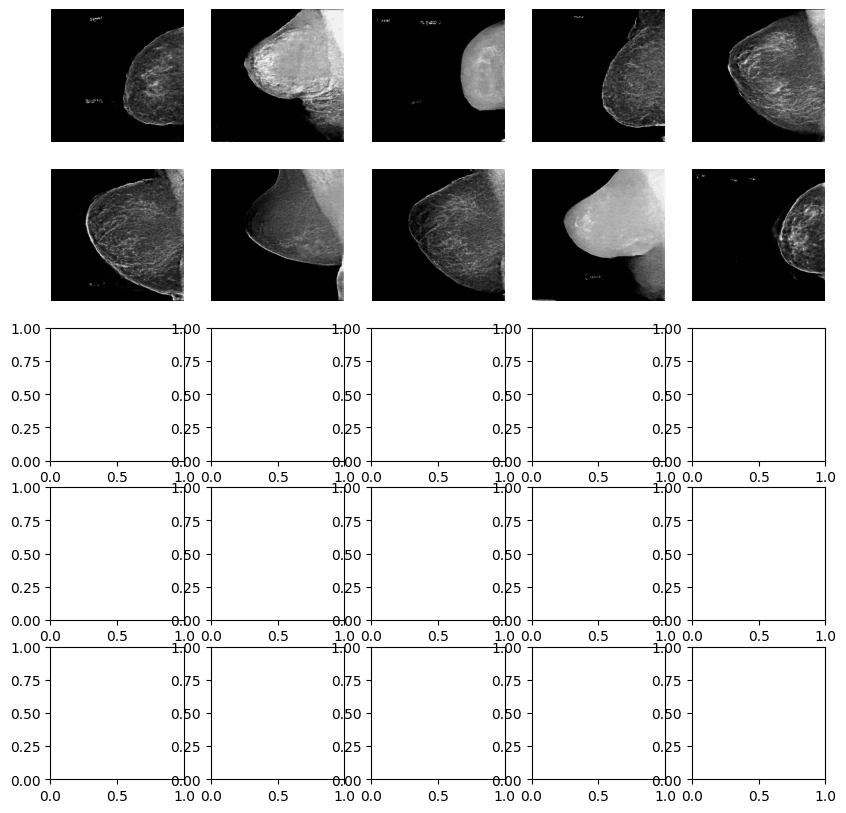

Starting epoch 6/100...
Epoch 6/100 | D_loss: -8.9971 | G_loss: 6.4618 | Time: 184.11s
Starting epoch 7/100...
Epoch 7/100 | D_loss: -8.2734 | G_loss: 6.3405 | Time: 182.28s
Starting epoch 8/100...
Epoch 8/100 | D_loss: -8.4122 | G_loss: 2.4170 | Time: 182.41s
Starting epoch 9/100...
Epoch 9/100 | D_loss: -8.3798 | G_loss: 8.0580 | Time: 182.98s
Starting epoch 10/100...
Epoch 10/100 | D_loss: -8.3779 | G_loss: 1.9901 | Time: 182.32s


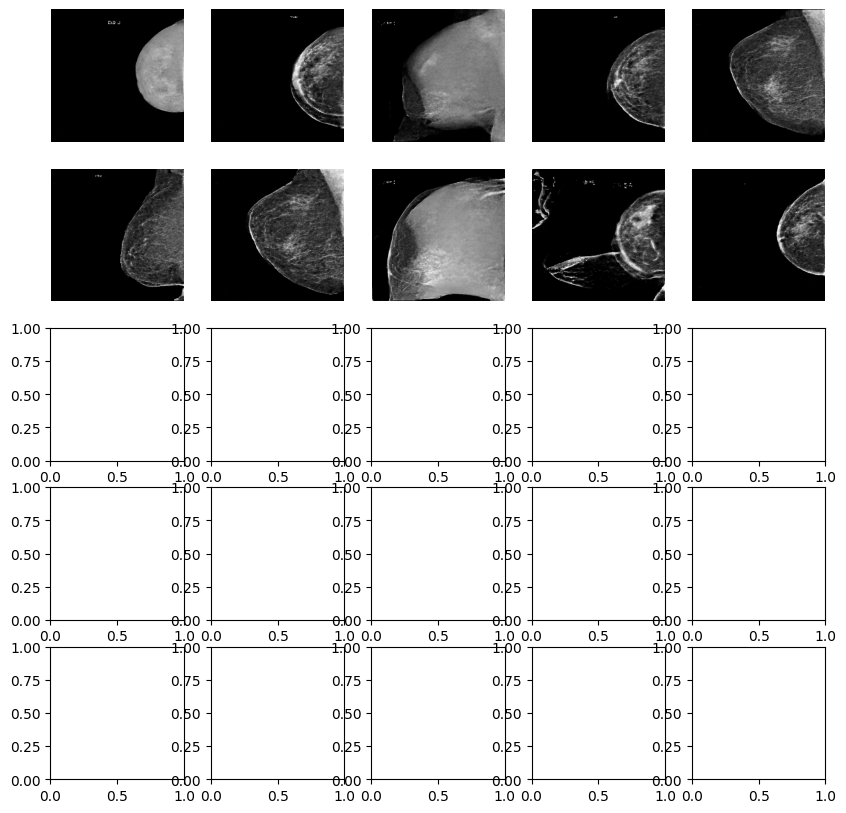

Starting epoch 11/100...
Epoch 11/100 | D_loss: -8.1903 | G_loss: 5.2465 | Time: 182.40s
Starting epoch 12/100...
Epoch 12/100 | D_loss: -8.3115 | G_loss: 0.0472 | Time: 183.19s
Starting epoch 13/100...
Epoch 13/100 | D_loss: -7.7400 | G_loss: -1.2076 | Time: 182.25s
Starting epoch 14/100...
Epoch 14/100 | D_loss: -8.2394 | G_loss: -6.2182 | Time: 182.11s
Starting epoch 15/100...
Epoch 15/100 | D_loss: -8.4983 | G_loss: -4.6171 | Time: 182.15s


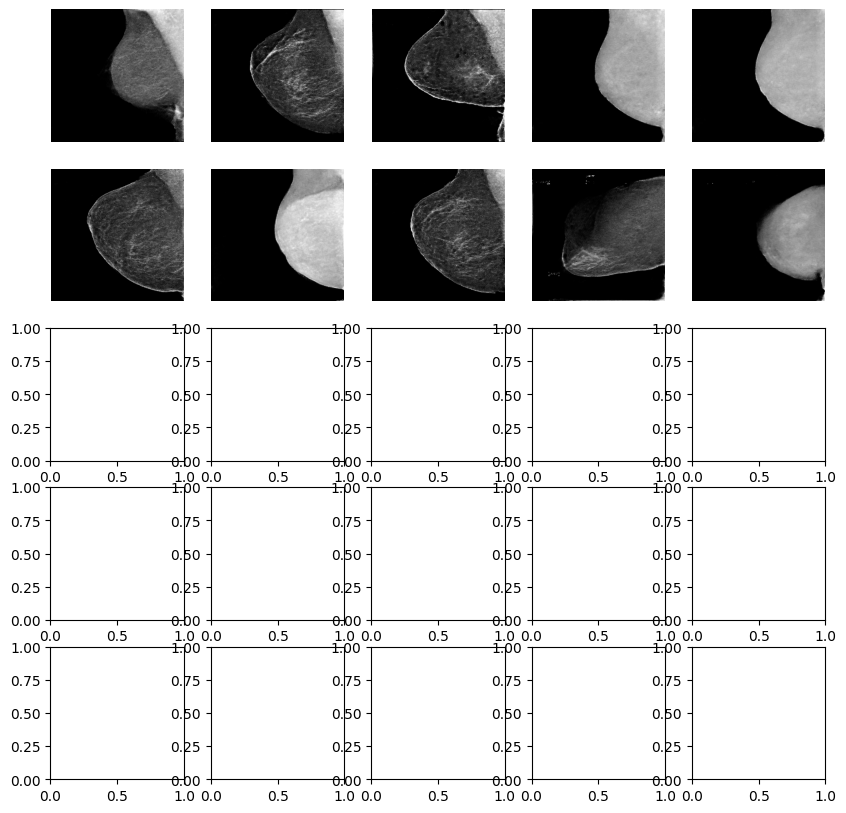

Starting epoch 16/100...
Epoch 16/100 | D_loss: -8.3742 | G_loss: -11.2414 | Time: 183.34s
Starting epoch 17/100...
Epoch 17/100 | D_loss: -8.4430 | G_loss: -9.8910 | Time: 182.23s
Starting epoch 18/100...
Epoch 18/100 | D_loss: -8.6605 | G_loss: -6.2173 | Time: 182.22s
Starting epoch 19/100...
Epoch 19/100 | D_loss: -8.3527 | G_loss: -13.3783 | Time: 184.07s
Starting epoch 20/100...
Epoch 20/100 | D_loss: -8.7170 | G_loss: -12.7281 | Time: 182.29s


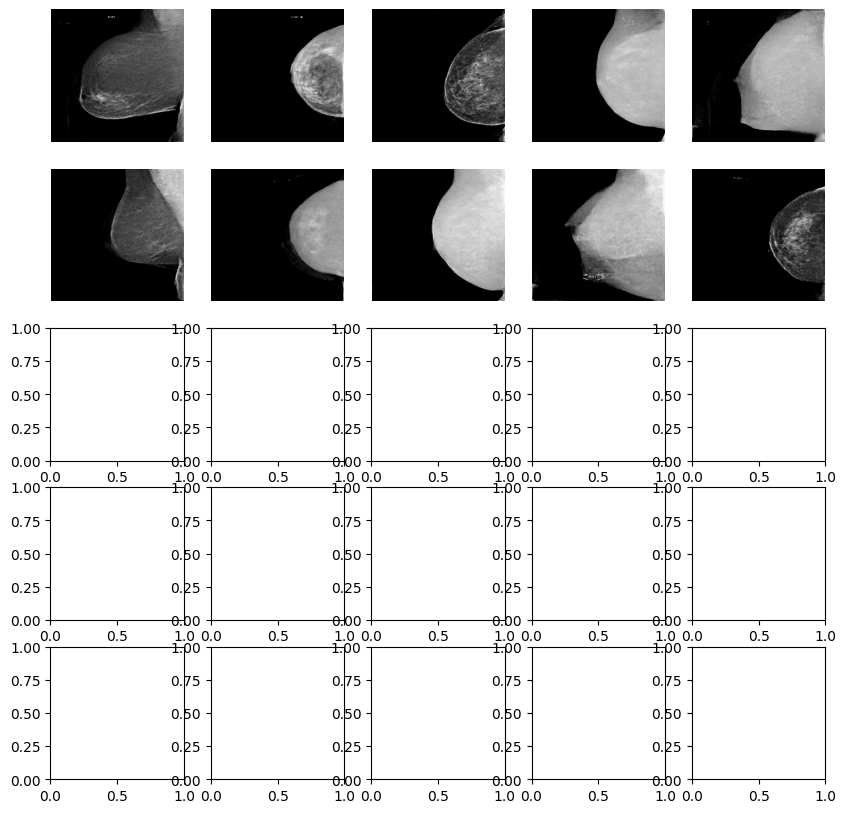

Starting epoch 21/100...
Epoch 21/100 | D_loss: -8.7643 | G_loss: -16.5915 | Time: 182.07s
Starting epoch 22/100...
Epoch 22/100 | D_loss: -8.9414 | G_loss: -11.4806 | Time: 181.90s
Starting epoch 23/100...
Epoch 23/100 | D_loss: -9.3078 | G_loss: -14.2410 | Time: 183.05s
Starting epoch 24/100...
Epoch 24/100 | D_loss: -9.1585 | G_loss: -11.5458 | Time: 184.79s
Starting epoch 25/100...
Epoch 25/100 | D_loss: -9.3352 | G_loss: -12.9285 | Time: 183.73s


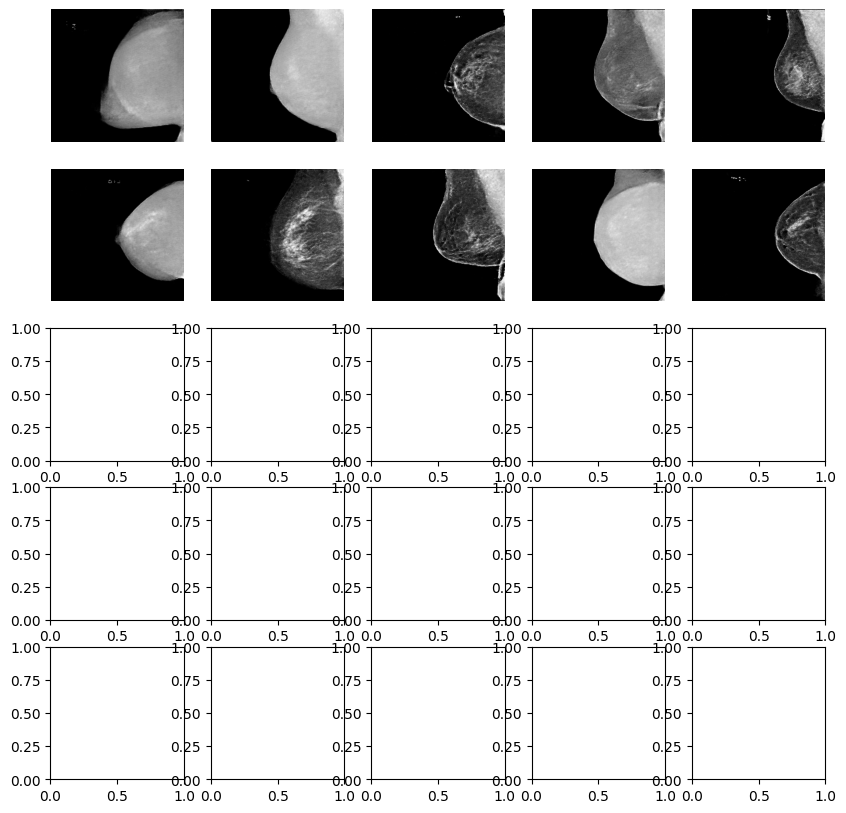

Starting epoch 26/100...
Epoch 26/100 | D_loss: -9.1808 | G_loss: -12.5938 | Time: 185.04s
Starting epoch 27/100...
Epoch 27/100 | D_loss: -9.4932 | G_loss: -14.0469 | Time: 185.16s
Starting epoch 28/100...
Epoch 28/100 | D_loss: -9.7095 | G_loss: -12.4840 | Time: 185.28s
Starting epoch 29/100...
Epoch 29/100 | D_loss: -9.3372 | G_loss: -13.5069 | Time: 184.74s
Starting epoch 30/100...
Epoch 30/100 | D_loss: -9.3040 | G_loss: -13.7405 | Time: 183.67s


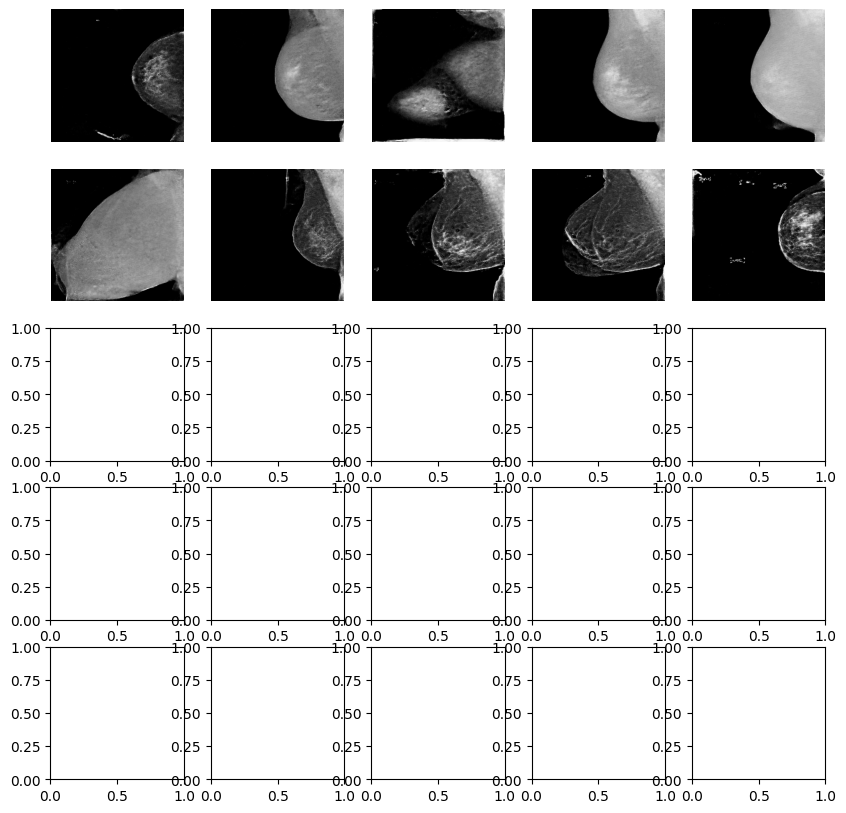

Starting epoch 31/100...
Epoch 31/100 | D_loss: -9.2656 | G_loss: -13.2521 | Time: 184.27s
Starting epoch 32/100...
Epoch 32/100 | D_loss: -8.9285 | G_loss: -10.6106 | Time: 184.40s
Starting epoch 33/100...
Epoch 33/100 | D_loss: -9.7850 | G_loss: -8.4849 | Time: 185.39s
Starting epoch 34/100...
Epoch 34/100 | D_loss: -9.2043 | G_loss: -10.3286 | Time: 184.24s
Starting epoch 35/100...
Epoch 35/100 | D_loss: -9.3939 | G_loss: -7.0866 | Time: 183.45s


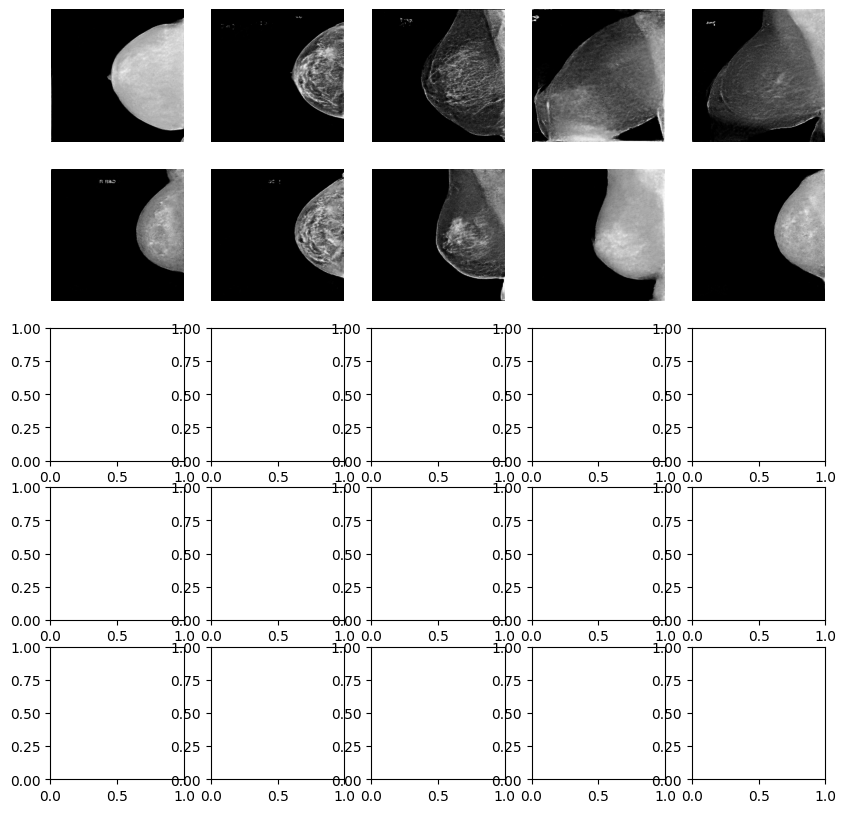

Starting epoch 36/100...
Epoch 36/100 | D_loss: -9.6243 | G_loss: -7.9972 | Time: 185.33s
Starting epoch 37/100...
Epoch 37/100 | D_loss: -9.5416 | G_loss: -6.9435 | Time: 183.24s
Starting epoch 38/100...
Epoch 38/100 | D_loss: -9.4808 | G_loss: -8.1052 | Time: 183.59s
Starting epoch 39/100...
Epoch 39/100 | D_loss: -9.2249 | G_loss: -6.2854 | Time: 184.18s
Starting epoch 40/100...
Epoch 40/100 | D_loss: -9.7432 | G_loss: -5.0234 | Time: 184.77s


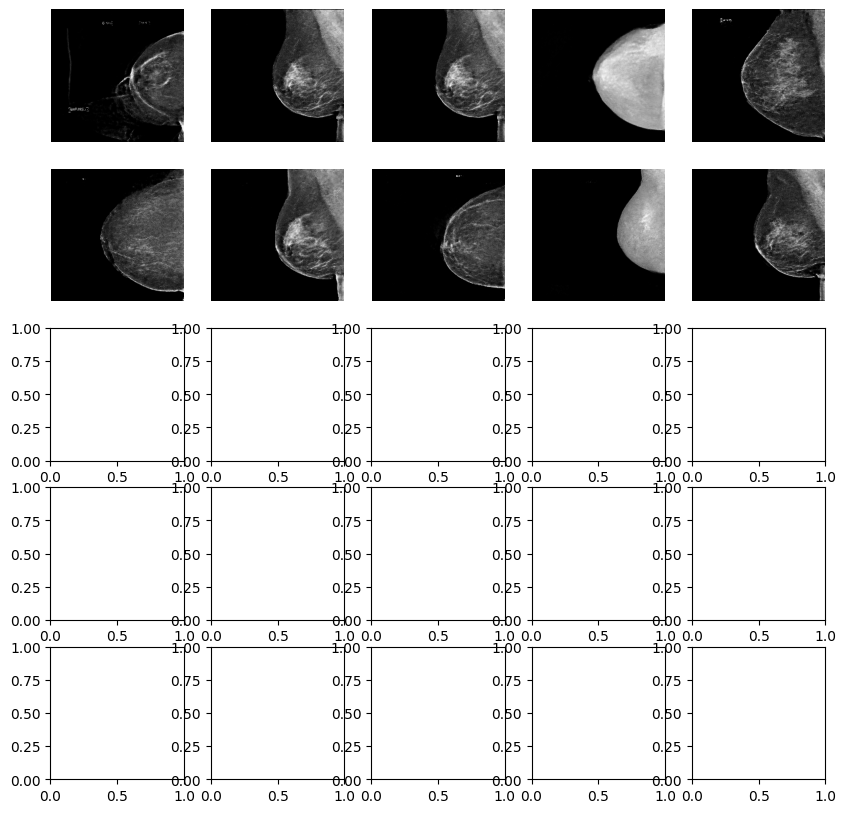

Starting epoch 41/100...
Epoch 41/100 | D_loss: -9.3978 | G_loss: -9.8759 | Time: 184.92s
Starting epoch 42/100...
Epoch 42/100 | D_loss: -9.2318 | G_loss: -6.5004 | Time: 185.51s
Starting epoch 43/100...
Epoch 43/100 | D_loss: -9.5209 | G_loss: -6.6459 | Time: 184.83s
Starting epoch 44/100...
Epoch 44/100 | D_loss: -9.4772 | G_loss: -3.6202 | Time: 183.63s
Starting epoch 45/100...
Epoch 45/100 | D_loss: -9.4724 | G_loss: -4.0663 | Time: 184.19s


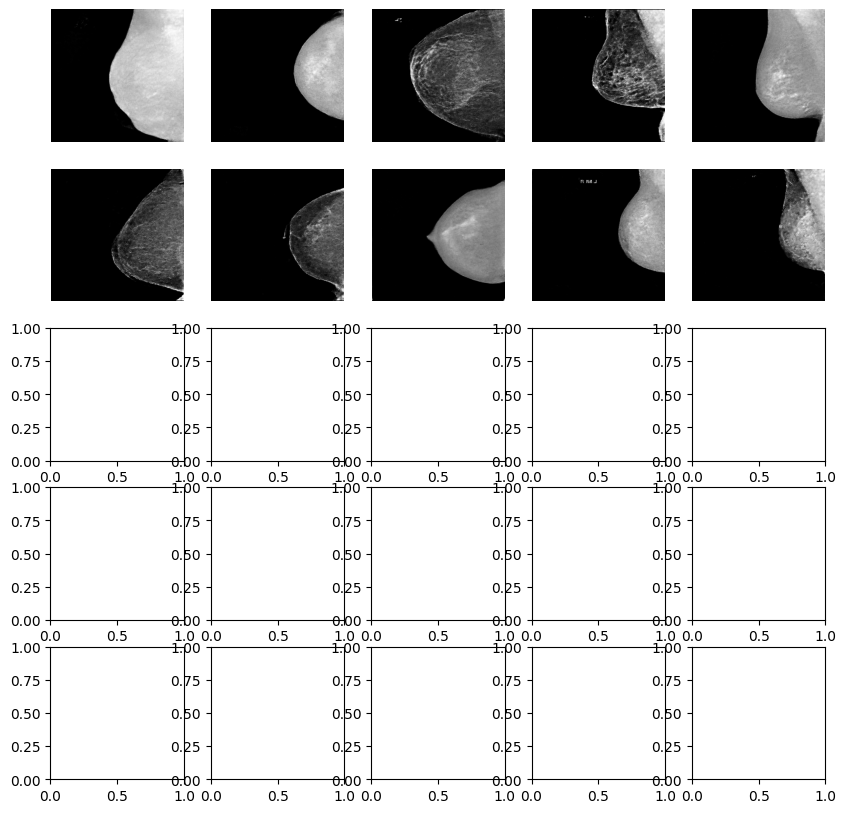

Starting epoch 46/100...
Epoch 46/100 | D_loss: -9.0057 | G_loss: -4.6728 | Time: 185.99s
Starting epoch 47/100...
Epoch 47/100 | D_loss: -8.8525 | G_loss: -7.6001 | Time: 183.43s
Starting epoch 48/100...
Epoch 48/100 | D_loss: -9.0036 | G_loss: -4.1997 | Time: 184.09s
Starting epoch 49/100...
Epoch 49/100 | D_loss: -9.1488 | G_loss: -2.4038 | Time: 185.34s
Starting epoch 50/100...
Epoch 50/100 | D_loss: -9.3809 | G_loss: -3.0850 | Time: 185.09s


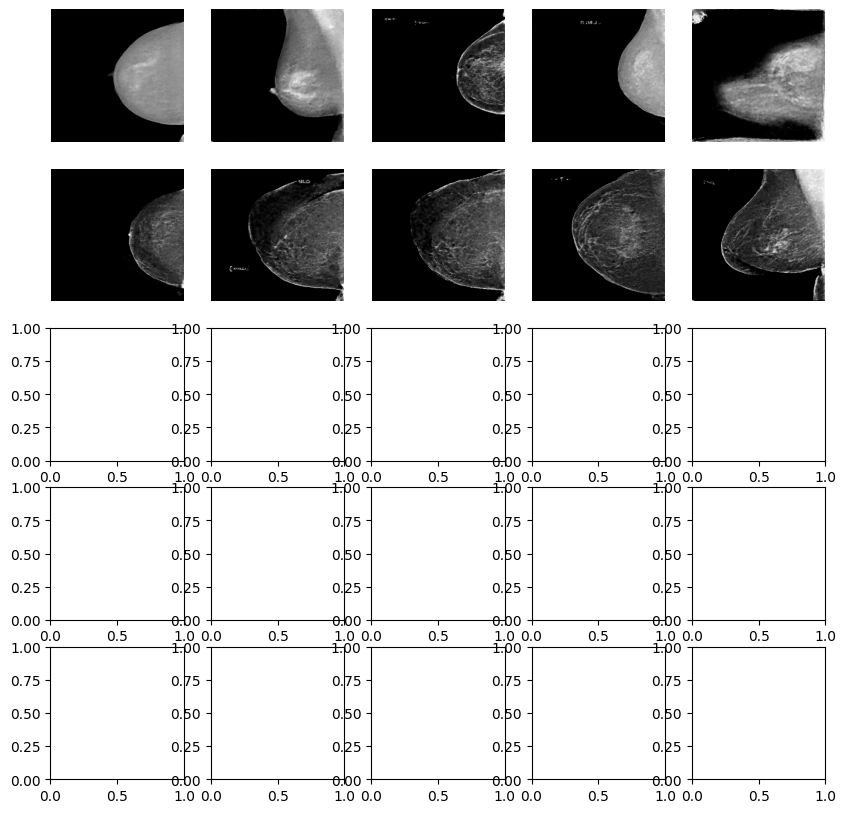

Starting epoch 51/100...


KeyboardInterrupt: 

In [ ]:
import time
train_dataset = load_dataset(batch_size)

def distributed_train_epoch(dataset):
    total_d_loss = 0.0
    total_g_loss = 0.0
    steps = 0

    for real_images in dataset:
        per_replica_d_loss, per_replica_g_loss = strategy.run(train_step, args=(real_images,))
        total_d_loss += strategy.reduce(tf.distribute.ReduceOp.MEAN, per_replica_d_loss, axis=None)
        total_g_loss += strategy.reduce(tf.distribute.ReduceOp.MEAN, per_replica_g_loss, axis=None)
        steps += 1

    return total_d_loss / steps, total_g_loss / steps

def train(epochs, generator, train_dataset, latent_dim=100, images_per_epoch=10):
    for epoch in range(epochs):
        print(f"Starting epoch {epoch + 1}/{epochs}...")
        start_time = time.time()

        d_loss, g_loss = distributed_train_epoch(train_dataset)

        print(f'Epoch {epoch + 1}/{epochs} | D_loss: {d_loss.numpy():.4f} | G_loss: {g_loss.numpy():.4f} | Time: {time.time() - start_time:.2f}s')

        # Generate and display images after each epoch
        if (epoch+1) % 5 == 0:
            generate_and_display_images(generator, num_images=images_per_epoch, latent_dim=latent_dim)

        # Save checkpoints periodically
        if (epoch + 1) % checkpoint_interval == 0:
            generator.save_weights(f'generator_epoch_{epoch+1}.weights.h5')
            discriminator.save_weights(f'discriminator_epoch_{epoch+1}.weights.h5')

train(epochs=100,
      generator=generator,
      train_dataset=train_dataset,
      latent_dim=100,
      images_per_epoch=10)